Data Loading & Initial EDA
Dataset Size: 1677 rows and 35 columns

The Dataset:


,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,...,80,1,10,2,3,10,0,7,8,0
1,1,35,Travel_Rarely,921,Sales,8,3,Other,1,1,...,80,1,4,3,3,4,2,0,3,0
2,2,32,Travel_Rarely,718,Sales,26,3,Marketing,1,3,...,80,2,4,3,3,3,2,1,2,0
3,3,38,Travel_Rarely,1488,Research & Development,2,3,Medical,1,3,...,80,0,15,1,1,6,0,0,2,0
4,4,50,Travel_Rarely,1017,Research & Development,5,4,Medical,1,2,...,80,0,31,0,3,31,14,4,10,1



Total Duplicate Rows: 0

Null Value Counts:


,Null_Count
Feature,
id,0
Age,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0



Target Variable Distribution
Attrition Distribution:
Attrition
0    1477
1     200
Name: count, dtype: int64


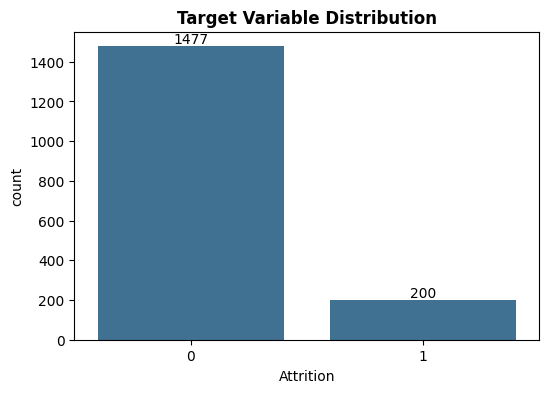


Data Cleaning & Encoding
Dataset shape after dropping constants: (1677, 31)
Categorical encoding complete.



,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,36,1,599,24,3,4,1,42,3,1,...,0,1,0,0,0,0,0,0,1,0
1,35,2,921,8,3,1,1,46,3,1,...,0,0,0,0,0,0,0,1,1,0
2,32,2,718,26,3,3,1,80,3,2,...,0,0,0,0,0,0,1,0,0,0
3,38,2,1488,2,3,3,0,40,3,2,...,0,0,0,0,0,0,0,0,1,0
4,50,2,1017,5,4,2,0,37,3,5,...,0,0,1,0,0,0,0,0,0,1


Pearson Correlation


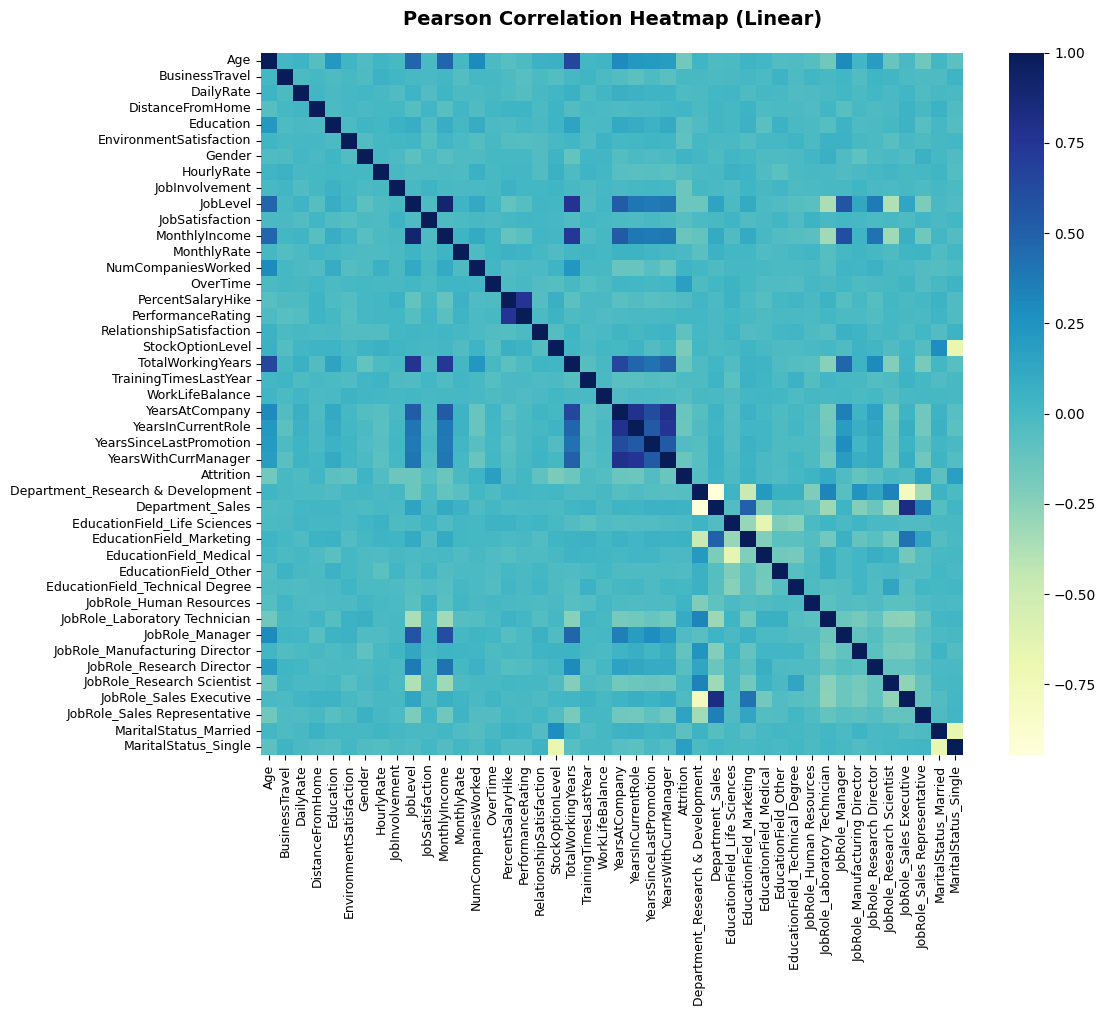


Multicollinearity (VIF) Check


,Feature,VIF_Score
0,PerformanceRating,174.802917
1,Department_Research & Development,163.418409
2,EducationField_Life Sciences,83.748435
3,Department_Sales,77.303359
4,EducationField_Medical,59.986899
5,PercentSalaryHike,46.157398
6,JobLevel,38.057255
7,Age,36.241408
8,MonthlyIncome,21.665881
9,JobInvolvement,18.920986


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Data Loading & Initial EDA")
dataset = pd.read_csv('4.csv')

ds = pd.DataFrame(
    dataset.values,
    columns=dataset.columns
)
print(f"Dataset Size: {dataset.shape[0]} rows and {dataset.shape[1]} columns\n")
print('The Dataset:')
display(ds.head())

null_counts = dataset.isnull().sum().to_frame(name='Null_Count')
null_counts.index.name = 'Feature'
duplicate_count = dataset.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")
print("\nNull Value Counts:")
display(null_counts)


print("\nTarget Variable Distribution")
print("Attrition Distribution:")
print(dataset['Attrition'].value_counts())
plt.figure(figsize=(6, 4))


ax = sns.countplot(x='Attrition', data=dataset, color='#3274A1')
ax.bar_label(ax.containers[0])
plt.title('Target Variable Distribution', fontweight='bold')
plt.show()

print("\nData Cleaning & Encoding")
#Drop non-predictive columns
cols_to_exclude = ['id', 'EmployeeCount', 'Over18', 'StandardHours']
dataset = dataset.drop(columns=[col for col in cols_to_exclude if col in dataset.columns], errors='ignore')
print(f"Dataset shape after dropping constants: {dataset.shape}")

#Label Encoding to binary and ordinal columns
le_cols = ['Gender', 'OverTime', 'BusinessTravel']
label_encoder = LabelEncoder()
for col in le_cols:
    if col in dataset.columns:
        dataset[col] = label_encoder.fit_transform(dataset[col])

#One-Hot Encoding to nominal columns
ohe_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
dataset = pd.get_dummies(dataset, columns=[col for col in ohe_cols if col in dataset.columns], drop_first=True, dtype=int)
print("Categorical encoding complete.\n")
display(dataset.head())
print("Pearson Correlation")

#Pearson Correlation Heatmap (Linear relationships)
plt.figure(figsize=(12, 10))
sns.heatmap(
    dataset.corr(method='pearson'),
    cmap='YlGnBu',
    annot=False,
    square=True,
    linewidths=0
)
plt.title('Pearson Correlation Heatmap (Linear)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("\nMulticollinearity (VIF) Check")
#Calculate VIF to find redundant features
X_vif = dataset.drop(columns=['Attrition'])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values(by='VIF_Score', ascending=False).reset_index(drop=True)
display(vif_data)

Dropping 'PerformanceRating' (VIF: 174.80)
Dropping 'Department_Research & Development' (VIF: 152.23)
Dropping 'EducationField_Life Sciences' (VIF: 41.15)
Dropping 'JobLevel' (VIF: 36.08)
Dropping 'Age' (VIF: 34.33)
Dropping 'Department_Sales' (VIF: 19.88)
Dropping 'PercentSalaryHike' (VIF: 18.06)
Dropping 'JobInvolvement' (VIF: 17.18)
Dropping 'WorkLifeBalance' (VIF: 16.75)
Dropping 'MonthlyIncome' (VIF: 12.66)
Dropping 'HourlyRate' (VIF: 12.10)
Dropping 'YearsAtCompany' (VIF: 11.65)

Dataset shape after VIF cleaning: (1677, 32)
Spearman Rank Correlation
Features flagged for removal (Spearman correlation between -0.03 and +0.03):
- BusinessTravel (Score: -0.0294)
- DailyRate (Score: -0.0210)
- MonthlyRate (Score: -0.0047)
- TrainingTimesLastYear (Score: -0.0050)
- EducationField_Medical (Score: -0.0097)
- EducationField_Technical Degree (Score: 0.0103)
- JobRole_Research Scientist (Score: 0.0044)
- JobRole_Sales Executive (Score: -0.0195)

Final optimized dataset shape ready for model

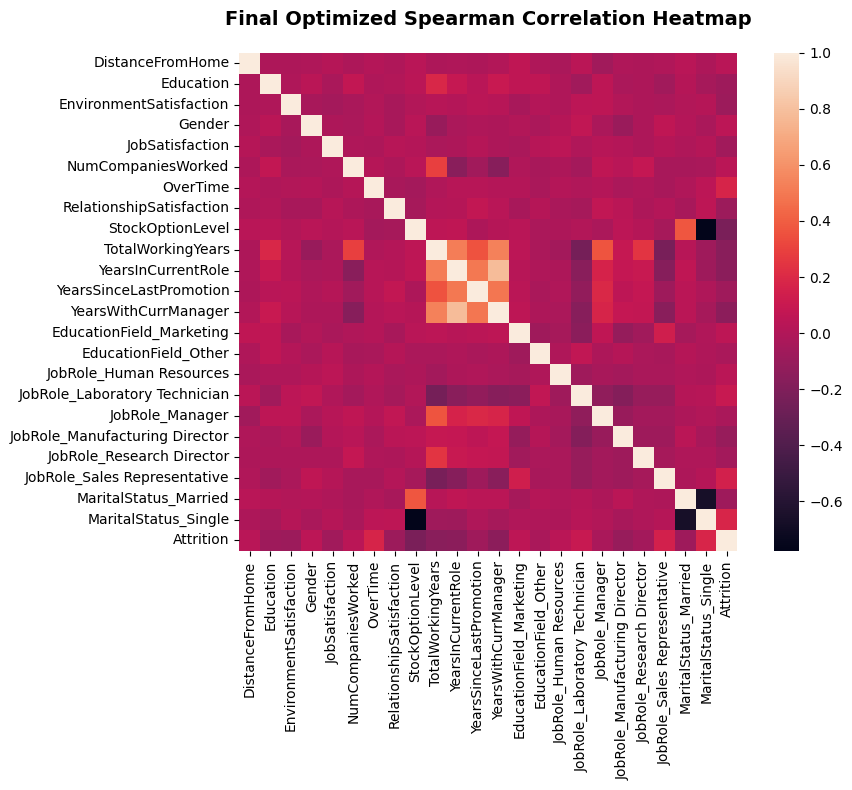

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Iteratively drop features with VIF > 10
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF_Score"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

X_vif = dataset.drop(columns=['Attrition'])
vif_threshold = 10.0

while True:
    vif_data = calculate_vif(X_vif)
    max_vif = vif_data['VIF_Score'].max()

    if max_vif > vif_threshold:
        # Find the feature with the highest VIF
        feature_to_drop = vif_data.loc[vif_data['VIF_Score'] == max_vif, 'Feature'].iloc[0]
        print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")
        X_vif = X_vif.drop(columns=[feature_to_drop])
    else:
        break

surviving_features = X_vif.columns.tolist() + ['Attrition']
dataset_vif_cleaned = dataset[surviving_features]

print(f"\nDataset shape after VIF cleaning: {dataset_vif_cleaned.shape}")

print("Spearman Rank Correlation")
#Calculate Spearman correlation (detects non-linear ordinal relationships)
spearman_corr = dataset_vif_cleaned.corr(method='spearman')['Attrition']

spearman_threshold = 0.03
weak_spearman_features = spearman_corr[abs(spearman_corr) < spearman_threshold].index.tolist()

if 'Attrition' in weak_spearman_features:
    weak_spearman_features.remove('Attrition')

print(f"Features flagged for removal (Spearman correlation between -{spearman_threshold} and +{spearman_threshold}):")
for feature in weak_spearman_features:
    print(f"- {feature} (Score: {spearman_corr[feature]:.4f})")

final_optimized_dataset = dataset_vif_cleaned.drop(columns=weak_spearman_features)

print(f"\nFinal optimized dataset shape ready for modeling: {final_optimized_dataset.shape}")

plt.figure(figsize=(10, 8))
final_corr = final_optimized_dataset.corr(method='spearman')
sns.heatmap(final_corr, cmap='rocket', annot=False, square=True, linewidths=0)
plt.title('Final Optimized Spearman Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

K-Fold, Training, Evaluation, & Visualization
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...

=== Final Comprehensive Model Comparison (Averaged across 5 Folds) ===


,Accuracy,Precision,Recall,F1 Score,AUC Score
Logistic Regression,0.8437,0.4156,0.535,0.4442,0.7945
KNN,0.7448,0.2582,0.525,0.3379,0.7064
Neural Network,0.8437,0.4301,0.440,0.4036,0.7479
K-Means (Unsupervised),0.4061,0.1440,0.805,0.2443,0.5785


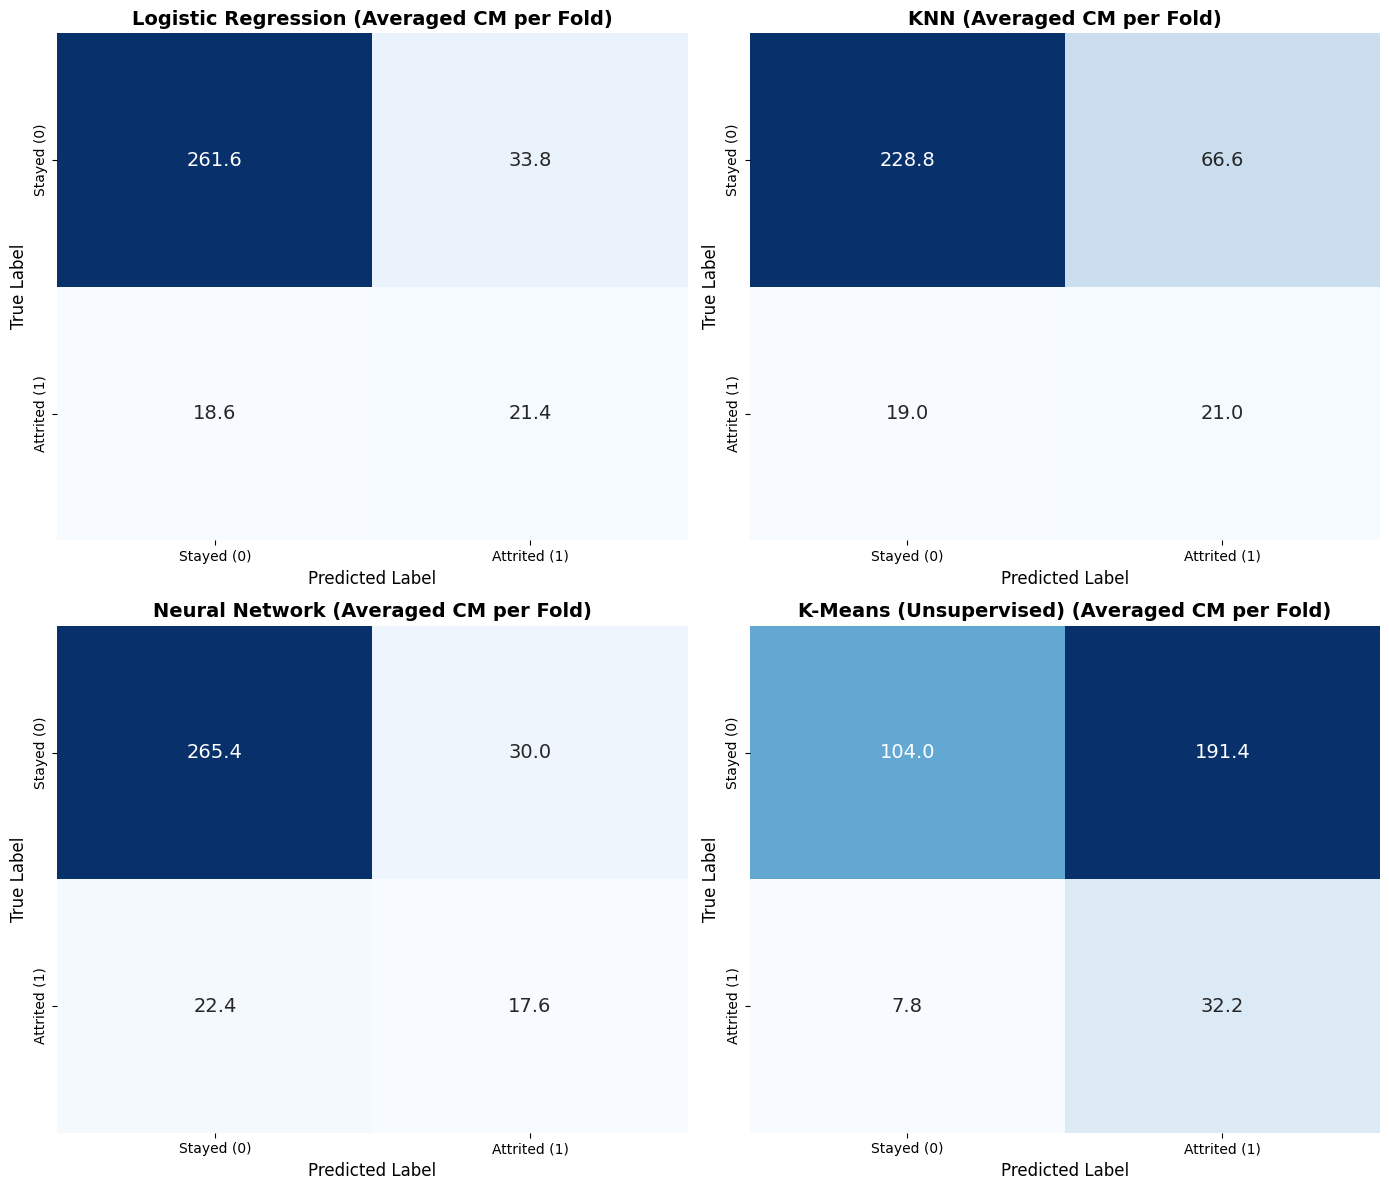

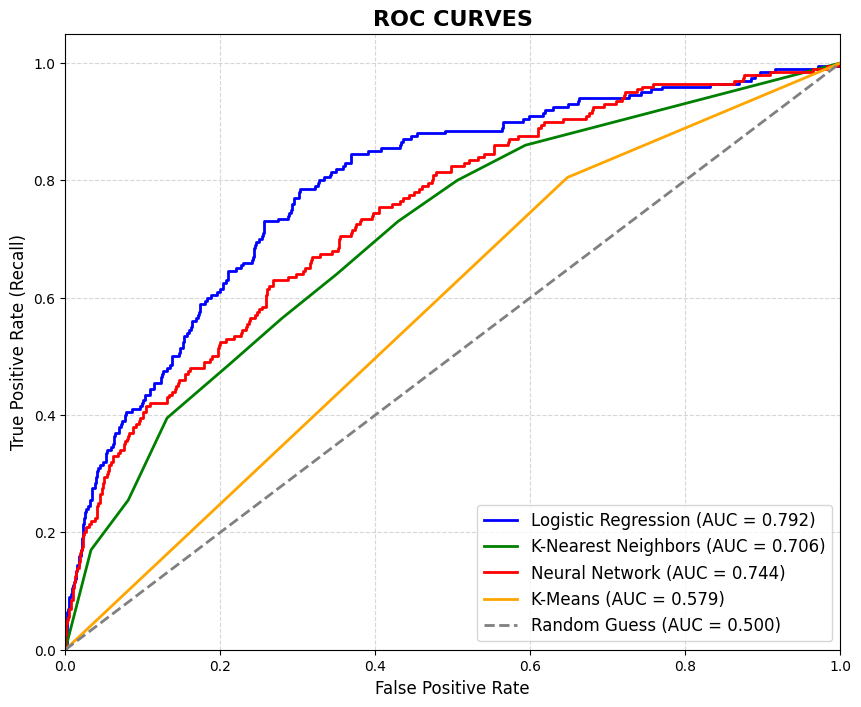

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, confusion_matrix, roc_curve, auc
from imblearn.combine import SMOTETomek
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

print("K-Fold, Training, Evaluation, & Visualization")
X = final_optimized_dataset.drop('Attrition', axis=1).values
y = final_optimized_dataset['Attrition'].values

#Setup K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_names = ['Logistic Regression', 'KNN', 'Neural Network', 'K-Means (Unsupervised)']
results = {name: {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []} for name in model_names}
fold_cms = {name: [] for name in model_names}
true_labels_all = []
lr_probs_all, knn_probs_all, nn_probs_all, km_probs_all = [], [], [], []

def get_optimal_predictions(y_t, y_p):
    precisions, recalls, thresholds = precision_recall_curve(y_t, y_p)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]
    return (y_p >= best_threshold).astype(int)

fold_no = 1
for train_index, val_index in skf.split(X, y):
    print(f"Processing Fold {fold_no}...")

    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Scale Data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)

    # Apply SMOTETomek (Only for Supervised models)
    smote_tomek = SMOTETomek(random_state=42)
    X_train_res, y_train_res = smote_tomek.fit_resample(X_train_scaled, y_train_fold)
    # Model 1: Logistic Regression
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_train_res, y_train_res)
    lr_prob = lr.predict_proba(X_val_scaled)[:, 1]
    lr_pred = get_optimal_predictions(y_val_fold, lr_prob)

    results['Logistic Regression']['acc'].append(accuracy_score(y_val_fold, lr_pred))
    results['Logistic Regression']['prec'].append(precision_score(y_val_fold, lr_pred, zero_division=0))
    results['Logistic Regression']['rec'].append(recall_score(y_val_fold, lr_pred))
    results['Logistic Regression']['f1'].append(f1_score(y_val_fold, lr_pred))
    results['Logistic Regression']['auc'].append(roc_auc_score(y_val_fold, lr_prob))
    fold_cms['Logistic Regression'].append(confusion_matrix(y_val_fold, lr_pred))
    lr_probs_all.extend(lr_prob)

    # Model 2: K-Nearest Neighbors (KNN)
    knn = KNeighborsClassifier(n_neighbors=9)
    knn.fit(X_train_res, y_train_res)
    knn_prob = knn.predict_proba(X_val_scaled)[:, 1]
    knn_pred = get_optimal_predictions(y_val_fold, knn_prob)

    results['KNN']['acc'].append(accuracy_score(y_val_fold, knn_pred))
    results['KNN']['prec'].append(precision_score(y_val_fold, knn_pred, zero_division=0))
    results['KNN']['rec'].append(recall_score(y_val_fold, knn_pred))
    results['KNN']['f1'].append(f1_score(y_val_fold, knn_pred))
    results['KNN']['auc'].append(roc_auc_score(y_val_fold, knn_prob))
    fold_cms['KNN'].append(confusion_matrix(y_val_fold, knn_pred))
    knn_probs_all.extend(knn_prob)

    # Model 3: Neural Network
    tf.random.set_seed(42)
    nn = Sequential([
        Input(shape=(X_train_res.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    nn.fit(X_train_res, y_train_res, epochs=50, batch_size=32, verbose=0)

    nn_prob = nn.predict(X_val_scaled, verbose=0).flatten()
    nn_pred = get_optimal_predictions(y_val_fold, nn_prob)

    results['Neural Network']['acc'].append(accuracy_score(y_val_fold, nn_pred))
    results['Neural Network']['prec'].append(precision_score(y_val_fold, nn_pred, zero_division=0))
    results['Neural Network']['rec'].append(recall_score(y_val_fold, nn_pred))
    results['Neural Network']['f1'].append(f1_score(y_val_fold, nn_pred))
    results['Neural Network']['auc'].append(roc_auc_score(y_val_fold, nn_prob))
    fold_cms['Neural Network'].append(confusion_matrix(y_val_fold, nn_pred))
    nn_probs_all.extend(nn_prob)

    # Model 4: K-Means (Unsupervised Baseline)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    km_pred = kmeans.predict(X_val_scaled)

    if y_val_fold[km_pred == 0].mean() > y_val_fold[km_pred == 1].mean():
        km_pred = np.where(km_pred == 0, 1, 0)
    km_prob = km_pred

    results['K-Means (Unsupervised)']['acc'].append(accuracy_score(y_val_fold, km_pred))
    results['K-Means (Unsupervised)']['prec'].append(precision_score(y_val_fold, km_pred, zero_division=0))
    results['K-Means (Unsupervised)']['rec'].append(recall_score(y_val_fold, km_pred))
    results['K-Means (Unsupervised)']['f1'].append(f1_score(y_val_fold, km_pred))
    results['K-Means (Unsupervised)']['auc'].append(roc_auc_score(y_val_fold, km_prob))
    fold_cms['K-Means (Unsupervised)'].append(confusion_matrix(y_val_fold, km_pred))
    km_probs_all.extend(km_prob)

    true_labels_all.extend(y_val_fold)
    fold_no += 1

# Table of Final Results
final_metrics = {}
for name in model_names:
    final_metrics[name] = {
        'Accuracy': np.mean(results[name]['acc']),
        'Precision': np.mean(results[name]['prec']),
        'Recall': np.mean(results[name]['rec']),
        'F1 Score': np.mean(results[name]['f1']),
        'AUC Score': np.mean(results[name]['auc'])
    }

comparison_df = pd.DataFrame(final_metrics).T
print("\n=== Final Comprehensive Model Comparison (Averaged across 5 Folds) ===")
display(comparison_df.round(4))

true_labels_all = np.array(true_labels_all)
lr_probs_all = np.array(lr_probs_all)
knn_probs_all = np.array(knn_probs_all)
nn_probs_all = np.array(nn_probs_all)
km_probs_all = np.array(km_probs_all)

# Plotting Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, name in enumerate(model_names):
    # Average the confusion matrices across the 5 folds
    avg_cm = np.mean(fold_cms[name], axis=0)

    sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 14})
    axes[i].set_title(f'{name} (Averaged CM per Fold)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].set_xticklabels(['Stayed (0)', 'Attrited (1)'])
    axes[i].set_yticklabels(['Stayed (0)', 'Attrited (1)'])

plt.tight_layout()
plt.show()

# Plotting ROC Curves
plt.figure(figsize=(10, 8))

models_probs = [
    ('Logistic Regression', lr_probs_all, 'blue'),
    ('K-Nearest Neighbors', knn_probs_all, 'green'),
    ('Neural Network', nn_probs_all, 'red'),
    ('K-Means', km_probs_all, 'orange')
]

for name, y_prob, color in models_probs:
    fpr, tpr, _ = roc_curve(true_labels_all, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC CURVES', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()